# $(SASA) Models - Kmeans$

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pickle
import numpy as np
import pandas as pd

from pmbrl.model2 import Base_Line_Simple_Model
# from pmbrl.model2 import Model, Regularized_Reference_Loss
from pmbrl.data import Experiment_Data, get_data_expanded

In [2]:
data = Experiment_Data()

data.load(path='../training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1588,10,65,"(0.1785778102029531, 1.438381745613701)","(-0.026, 0.376, -0.03, -0.258)",1,1.0,"(-0.019, 0.563, -0.035, -0.37)",0.0,1.0,"(-0.007, 0.376, -0.042, -0.266)"
952,37,38,"(0.4545373771214862, 0.5810082803318615)","(0.098, 0.939, 0.001, -1.183)",1,1.0,"(0.117, 1.136, -0.023, -1.523)",1.0,1.0,"(0.139, 1.333, -0.053, -1.871)"
563,0,21,"(0.3094422912440924, 0.4357216409942268)","(0.028, 0.011, 0.021, -0.041)",1,1.0,"(0.028, 0.21, 0.02, -0.429)",1.0,1.0,"(0.033, 0.409, 0.012, -0.817)"
1614,2,66,"(0.0609425168772551, 1.2010637267216533)","(0.047, 0.02, -0.045, 0.002)",0,1.0,"(0.047, -0.167, -0.045, 0.114)",0.0,1.0,"(0.044, -0.354, -0.042, 0.227)"
2277,19,90,"(0.3414097641144769, 0.5159987201834333)","(0.005, 0.207, 0.009, -0.164)",0,1.0,"(0.009, 0.01, 0.006, 0.184)",0.0,1.0,"(0.009, -0.188, 0.01, 0.53)"
...,...,...,...,...,...,...,...,...,...,...
278,30,9,"(0.0614156820293939, 0.6127438843111195)","(0.009, -0.042, 0.133, 0.493)",1,1.0,"(0.008, 0.148, 0.143, 0.296)",0.0,1.0,"(0.011, -0.045, 0.149, 0.561)"
507,59,19,"(0.0642916329828742, 1.239005358213764)","(0.046, 0.211, 0.084, 0.259)",0,1.0,"(0.05, 0.023, 0.089, 0.384)",1.0,1.0,"(0.051, 0.21, 0.097, 0.28)"
373,19,13,"(0.2403247570594251, 0.7298838219922094)","(0.137, -0.158, -0.058, 0.235)",1,1.0,"(0.134, 0.035, -0.054, -0.002)",0.0,1.0,"(0.135, -0.157, -0.054, 0.208)"
2264,6,90,"(0.3414097641144769, 0.5159987201834333)","(-0.03, 0.017, 0.036, 0.026)",0,1.0,"(-0.03, -0.181, 0.037, 0.384)",1.0,1.0,"(-0.034, 0.015, 0.044, 0.053)"


In [3]:
expansions = {
    's': ['s0', 's1', 's2', 's3'],
    's_': ['s_0', 's_1', 's_2', 's_3'],
    'p': ['p0', 'p1'],
}

df = get_data_expanded(data.build_training_dataset(), expansions)
# df = df.loc[df['episode']<15].copy()
df

,step,episode,p,s,a,r,s_,a_,r_,s__,s0,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1
1915,19,76,"(0.0250474928798763, 0.8242933987226606)","(-0.061, -0.903, 0.132, 0.96)",1,1.0,"(-0.079, -0.714, 0.151, 0.817)",0.0,1.0,"(-0.094, -0.905, 0.168, 1.01)",-0.061,-0.903,0.132,0.960,-0.079,-0.714,0.151,0.817,0.025047,0.824293
1789,6,70,"(0.6624936831395084, 0.7113031322267719)","(-0.045, -0.373, 0.05, 0.747)",0,1.0,"(-0.052, -0.572, 0.064, 1.114)",0.0,1.0,"(-0.064, -0.77, 0.087, 1.486)",-0.045,-0.373,0.050,0.747,-0.052,-0.572,0.064,1.114,0.662494,0.711303
2016,10,80,"(0.077800491974935, 0.5006250071926374)","(-0.021, -0.434, -0.003, 0.498)",1,1.0,"(-0.029, -0.239, 0.007, 0.21)",1.0,1.0,"(-0.034, -0.044, 0.012, -0.075)",-0.021,-0.434,-0.003,0.498,-0.029,-0.239,0.007,0.210,0.077800,0.500625
1827,8,72,"(0.0299192122981388, 0.6251069830910954)","(0.111, 0.723, -0.136, -1.041)",0,1.0,"(0.125, 0.533, -0.157, -0.853)",0.0,1.0,"(0.136, 0.343, -0.174, -0.67)",0.111,0.723,-0.136,-1.041,0.125,0.533,-0.157,-0.853,0.029919,0.625107
98,10,5,"(0.3551867425587211, 0.959194989729514)","(0.048, -0.349, -0.015, 0.333)",0,1.0,"(0.041, -0.539, -0.009, 0.517)",1.0,1.0,"(0.03, -0.349, 0.002, 0.328)",0.048,-0.349,-0.015,0.333,0.041,-0.539,-0.009,0.517,0.355187,0.959195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2294,36,90,"(0.3414097641144769, 0.5159987201834333)","(-0.029, -0.006, 0.161, 0.526)",0,1.0,"(-0.029, -0.205, 0.171, 0.922)",0.0,1.0,"(-0.033, -0.405, 0.19, 1.321)",-0.029,-0.006,0.161,0.526,-0.029,-0.205,0.171,0.922,0.341410,0.515999
295,11,10,"(0.0746887501825485, 0.1350490291932765)","(0.045, -0.69, -0.029, 2.496)",0,1.0,"(0.031, -0.919, 0.021, 3.528)",1.0,1.0,"(0.013, -0.689, 0.092, 2.487)",0.045,-0.690,-0.029,2.496,0.031,-0.919,0.021,3.528,0.074689,0.135049
875,7,35,"(0.7510043618705947, 0.8768677218696304)","(-0.092, -0.601, 0.178, 1.196)",0,1.0,"(-0.104, -0.799, 0.202, 1.559)",0.0,1.0,"(-0.12, -0.997, 0.234, 1.924)",-0.092,-0.601,0.178,1.196,-0.104,-0.799,0.202,1.559,0.751004,0.876868
267,19,9,"(0.0614156820293939, 0.6127438843111195)","(0.008, -0.222, 0.07, 0.442)",1,1.0,"(0.004, -0.03, 0.079, 0.228)",0.0,1.0,"(0.003, -0.224, 0.084, 0.479)",0.008,-0.222,0.070,0.442,0.004,-0.030,0.079,0.228,0.061416,0.612744


# Initialization by Random Partitioning

In [4]:
k = 5
models = [Base_Line_Simple_Model() for _ in range(k)]

In [5]:
groups = np.random.randint(low=0, high=k, size=df.episode.unique().shape[0])
df['group'] = np.nan

for i, g in enumerate(groups):
    df.loc[df['episode']==i,'group'] = g
df

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1,group
1915,19,76,"(0.0250474928798763, 0.8242933987226606)","(-0.061, -0.903, 0.132, 0.96)",1,1.0,"(-0.079, -0.714, 0.151, 0.817)",0.0,1.0,"(-0.094, -0.905, 0.168, 1.01)",...,-0.903,0.132,0.960,-0.079,-0.714,0.151,0.817,0.025047,0.824293,4.0
1789,6,70,"(0.6624936831395084, 0.7113031322267719)","(-0.045, -0.373, 0.05, 0.747)",0,1.0,"(-0.052, -0.572, 0.064, 1.114)",0.0,1.0,"(-0.064, -0.77, 0.087, 1.486)",...,-0.373,0.050,0.747,-0.052,-0.572,0.064,1.114,0.662494,0.711303,0.0
2016,10,80,"(0.077800491974935, 0.5006250071926374)","(-0.021, -0.434, -0.003, 0.498)",1,1.0,"(-0.029, -0.239, 0.007, 0.21)",1.0,1.0,"(-0.034, -0.044, 0.012, -0.075)",...,-0.434,-0.003,0.498,-0.029,-0.239,0.007,0.210,0.077800,0.500625,1.0
1827,8,72,"(0.0299192122981388, 0.6251069830910954)","(0.111, 0.723, -0.136, -1.041)",0,1.0,"(0.125, 0.533, -0.157, -0.853)",0.0,1.0,"(0.136, 0.343, -0.174, -0.67)",...,0.723,-0.136,-1.041,0.125,0.533,-0.157,-0.853,0.029919,0.625107,0.0
98,10,5,"(0.3551867425587211, 0.959194989729514)","(0.048, -0.349, -0.015, 0.333)",0,1.0,"(0.041, -0.539, -0.009, 0.517)",1.0,1.0,"(0.03, -0.349, 0.002, 0.328)",...,-0.349,-0.015,0.333,0.041,-0.539,-0.009,0.517,0.355187,0.959195,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2294,36,90,"(0.3414097641144769, 0.5159987201834333)","(-0.029, -0.006, 0.161, 0.526)",0,1.0,"(-0.029, -0.205, 0.171, 0.922)",0.0,1.0,"(-0.033, -0.405, 0.19, 1.321)",...,-0.006,0.161,0.526,-0.029,-0.205,0.171,0.922,0.341410,0.515999,2.0
295,11,10,"(0.0746887501825485, 0.1350490291932765)","(0.045, -0.69, -0.029, 2.496)",0,1.0,"(0.031, -0.919, 0.021, 3.528)",1.0,1.0,"(0.013, -0.689, 0.092, 2.487)",...,-0.690,-0.029,2.496,0.031,-0.919,0.021,3.528,0.074689,0.135049,4.0
875,7,35,"(0.7510043618705947, 0.8768677218696304)","(-0.092, -0.601, 0.178, 1.196)",0,1.0,"(-0.104, -0.799, 0.202, 1.559)",0.0,1.0,"(-0.12, -0.997, 0.234, 1.924)",...,-0.601,0.178,1.196,-0.104,-0.799,0.202,1.559,0.751004,0.876868,1.0
267,19,9,"(0.0614156820293939, 0.6127438843111195)","(0.008, -0.222, 0.07, 0.442)",1,1.0,"(0.004, -0.03, 0.079, 0.228)",0.0,1.0,"(0.003, -0.224, 0.084, 0.479)",...,-0.222,0.070,0.442,0.004,-0.030,0.079,0.228,0.061416,0.612744,2.0


## Initial Training 

In [6]:
def train_models(models, train_dataset):
    train_data = [None for _ in models]

    for g, model in enumerate(models):
        # print('train model: ', g)
        group_data = train_dataset.loc[train_dataset['group']==g]
        x, y = model.get_features_targets(group_data)
        trainer = model.train(x, y, num_epochs=1000)
        train_data[g] = data.get_training_data(trainer, inference_schema=model.inference_schema)
    
    return train_data


In [7]:
train_data = train_models(models, df[[
    's', 's_', 's__', 'a', 'a_', 'r', 'p', 'group'
]])

train_data[0].head()

,epoch,mse_s,transition,reward
0,0,"[0.03991653025150299, 0.5157346725463867, 0.05...",1.452444,1.472160
1,1,"[0.03973627835512161, 0.5110982656478882, 0.05...",1.441208,1.473154
2,2,"[0.039559509605169296, 0.5064995884895325, 0.0...",1.430071,1.474207
3,3,"[0.03938637673854828, 0.5019404888153076, 0.05...",1.419034,1.475307
4,4,"[0.0392167903482914, 0.49742355942726135, 0.05...",1.408096,1.476434


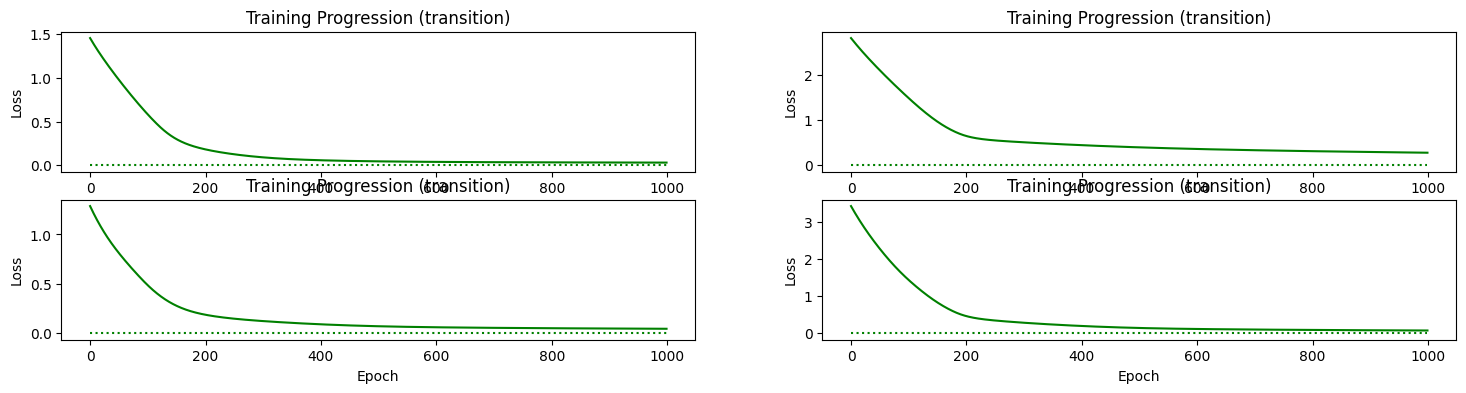

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(18, 4))

data.plot_training_loss(axs[0][0], train_data[0].transition)
data.plot_training_loss(axs[0][1], train_data[1].transition)
data.plot_training_loss(axs[1][0], train_data[2].transition)
data.plot_training_loss(axs[1][1], train_data[3].transition)

plt.show()

# Predict 

In [9]:
def evaluate(models, df):
    def predict(model):
        prediction_dataset = df.copy()
        prediction_dataset[model.grouped_targets_lables] = prediction_dataset.apply(lambda row: data._predict_from_row(row, model), axis=1, result_type='expand')
        return prediction_dataset

    predictions = [predict(m) for m in models]

    prediction_dataset = df.copy()
    for i, pred in enumerate(predictions):
        prediction_dataset[f'estimated_s_model_{i}'] = pred['estimated_s']
        
        results = data.get_evaluation_metrics(pred, p=False)
        prediction_dataset[f'rse_model_{i}'] = results['rse']
        prediction_dataset[f'rse_normalized_model_{i}'] = results['rse_normalized']

        prediction_dataset[f'rse_s0_model_{i}'] = results['rse_s0']
        prediction_dataset[f'rse_s1_model_{i}'] = results['rse_s1']
        prediction_dataset[f'rse_s2_model_{i}'] = results['rse_s2']
        prediction_dataset[f'rse_s3_model_{i}'] = results['rse_s3']

        prediction_dataset[f'rse_s0_normalized_model_{i}'] = results['rse_s0_normalized']
        prediction_dataset[f'rse_s1_normalized_model_{i}'] = results['rse_s1_normalized']
        prediction_dataset[f'rse_s2_normalized_model_{i}'] = results['rse_s2_normalized']
        prediction_dataset[f'rse_s3_normalized_model_{i}'] = results['rse_s3_normalized']


    return prediction_dataset

In [10]:
prediction_dataset = evaluate(models, df)
prediction_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_model_4,rse_normalized_model_4,rse_s0_model_4,rse_s1_model_4,rse_s2_model_4,rse_s3_model_4,rse_s0_normalized_model_4,rse_s1_normalized_model_4,rse_s2_normalized_model_4,rse_s3_normalized_model_4
1915,19,76,"(0.0250474928798763, 0.8242933987226606)","(-0.061, -0.903, 0.132, 0.96)",1,1.0,"(-0.079, -0.714, 0.151, 0.817)",0.0,1.0,"(-0.094, -0.905, 0.168, 1.01)",...,0.261,0.502222,0.015,0.018,0.039,0.189,0.409659,0.422199,0.592326,0.584704
1789,6,70,"(0.6624936831395084, 0.7113031322267719)","(-0.045, -0.373, 0.05, 0.747)",0,1.0,"(-0.052, -0.572, 0.064, 1.114)",0.0,1.0,"(-0.064, -0.77, 0.087, 1.486)",...,0.120,0.478814,0.025,0.019,0.001,0.075,0.413822,0.422373,0.501199,0.577860
2016,10,80,"(0.077800491974935, 0.5006250071926374)","(-0.021, -0.434, -0.003, 0.498)",1,1.0,"(-0.029, -0.239, 0.007, 0.21)",1.0,1.0,"(-0.034, -0.044, 0.012, -0.075)",...,0.065,0.479766,0.016,0.007,0.006,0.036,0.410075,0.420282,0.513189,0.575519
1827,8,72,"(0.0299192122981388, 0.6251069830910954)","(0.111, 0.723, -0.136, -1.041)",0,1.0,"(0.125, 0.533, -0.157, -0.853)",0.0,1.0,"(0.136, 0.343, -0.174, -0.67)",...,0.065,0.477184,0.003,0.039,0.002,0.021,0.404663,0.425858,0.503597,0.574619
98,10,5,"(0.3551867425587211, 0.959194989729514)","(0.048, -0.349, -0.015, 0.333)",0,1.0,"(0.041, -0.539, -0.009, 0.517)",1.0,1.0,"(0.03, -0.349, 0.002, 0.328)",...,0.084,0.478601,0.025,0.010,0.002,0.047,0.413822,0.420805,0.503597,0.576180


In [11]:
def reagroup(prediction_dataset):
    agg_results = prediction_dataset[['episode'] + [
    f'rse_model_{i}' for i,_ in enumerate(models)
    #     'rse_model_0',
    #     'rse_model_1',
    #     'rse_model_2',
    #     'rse_model_3',
    #     'rse_model_4',
    ]].groupby('episode').mean().reset_index()

    agg_results['best_model'] = agg_results.apply(lambda row: np.argmin(row[1:].values), axis=1)
    print(agg_results['best_model'].value_counts())

    prediction_dataset['best_model'] = prediction_dataset.apply(lambda row: agg_results[agg_results['episode']==row['episode']].best_model.values[0],axis=1)
    prediction_dataset['best_rse'] = prediction_dataset.apply(lambda row: row[f'rse_model_{row.best_model}'],axis=1)

    return prediction_dataset

In [12]:
prediction_dataset = reagroup(prediction_dataset)
prediction_dataset[['best_rse']].describe()

best_model
4    39
1    24
0    16
2    11
3    10
Name: count, dtype: int64


,best_rse
count,2504.000000
mean,0.184778
std,0.222241
min,0.016000
25%,0.086000
50%,0.139000
75%,0.205250
max,4.434000


# LOOP

In [13]:

# while True: 
for _ in range(10): 
    check = prediction_dataset[prediction_dataset['group'] != prediction_dataset['best_model']].shape[0]
    print(f'epis_changed: {check}')
    if check == 0:
        break
    

    train_df = prediction_dataset[['s', 's_', 's__', 'a', 'a_', 'r', 'p']].copy()
    train_df['group'] = prediction_dataset['best_model']
    train_data = train_models(models, train_df)

    prediction_dataset = evaluate(models, prediction_dataset)

    prediction_dataset = reagroup(prediction_dataset)
    print(prediction_dataset[['best_rse']].mean())
    

epis_changed: 1698
best_model
4    36
2    23
1    16
3    14
0    11
Name: count, dtype: int64
best_rse    0.100879
dtype: float64
epis_changed: 1790
best_model
4    36
2    24
1    14
0    13
3    13
Name: count, dtype: int64
best_rse    0.081504
dtype: float64
epis_changed: 1796
best_model
4    36
2    25
0    16
1    12
3    11
Name: count, dtype: int64
best_rse    0.068583
dtype: float64
epis_changed: 1772
best_model
4    36
2    27
0    17
3    10
1    10
Name: count, dtype: int64
best_rse    0.06114
dtype: float64
epis_changed: 1770
best_model
4    36
2    27
0    18
3    10
1     9
Name: count, dtype: int64
best_rse    0.056181
dtype: float64
epis_changed: 1754
best_model
4    36
2    27
0    18
3    10
1     9
Name: count, dtype: int64
best_rse    0.051612
dtype: float64
epis_changed: 1754
best_model
4    36
2    27
0    19
3     9
1     9
Name: count, dtype: int64
best_rse    0.048355
dtype: float64
epis_changed: 1754
best_model
4    36
2    27
0    20
1     9
3     8
Name: c

# Export Model 

In [14]:
import pickle

exp = {
    "data": prediction_dataset,
    "model": models 
}

nome_do_arquivo = 'kmodels.pkl'
with open(nome_do_arquivo, 'wb') as arquivo:
    pickle.dump(exp, arquivo)